In [26]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


sns.set_style("whitegrid")

## Step 1: Load the Dataset

The cleaned Titanic dataset from Week 2 is loaded for building classification models.

In [27]:
# Load cleaned dataset

df = pd.read_csv("cleaned_titanic.csv")

# Display first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.565736,1,0,A/5 21171,-0.502445,Unknown,2
1,3,1,3,"Heikkinen, Miss. Laina",0,-0.258337,0,0,STON/O2. 3101282,-0.488854,Unknown,2
2,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.433312,1,0,113803,0.420730,C123,2
3,5,0,3,"Allen, Mr. William Henry",1,0.433312,0,0,373450,-0.486337,Unknown,2
4,6,0,3,"Moran, Mr. James",1,-0.104637,0,0,330877,-0.478116,Unknown,1


## Step 2: Explore the Dataset

Before training a machine learning model, it is important to understand the dataset, including its shape, columns, and data types.

In [28]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (775, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked         int64
dtype: object


In [29]:
# Check missing values

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## Step 3: Select Features and Target Variable

For classification, the model needs:

- Features (X): Information used to make predictions.
- Target (y): The value we want to predict.

In this project, the target variable is **Survived**.

In [30]:
# Select features and target

# Select useful features and target

X = df.drop(
    columns=[
        "Survived",
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

y = df["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures Used:")
print(X.columns.tolist())

Features Shape: (775, 7)
Target Shape: (775,)

Features Used:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [31]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (620, 7)
Testing Features : (155, 7)
Training Labels : (620,)
Testing Labels  : (155,)


# Day 1 Summary

Today, the following tasks were completed:

- Imported required libraries
- Loaded the cleaned Titanic dataset
- Explored the dataset
- Verified that there are no missing values
- Selected the feature matrix (X) and target variable (y)
- Split the dataset into training and testing sets

The dataset is now fully prepared for training classification models on Day 2.

---

# 🤖 Day 2 – Logistic Regression Model

## Objective

In this section, we will train our first machine learning classification model using **Logistic Regression**.

The model will learn patterns from the training dataset and predict whether a passenger survived the Titanic disaster.

Finally, we will evaluate the model using multiple classification metrics.

In [32]:
# Importing classification libraries

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Step 5 — Train Logistic Regression

The Logistic Regression algorithm is trained using the training dataset prepared during Day 1.

In [33]:
# Create Logistic Regression model

log_model = LogisticRegression(max_iter=1000)

# Train the model

log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


##  Step 6 — Make Predictions

Now that the Logistic Regression model has been trained, we use it to predict survival outcomes for the testing dataset.

These predictions will be compared with the actual values to evaluate the model's performance.

In [34]:
# Make predictions on the test data

y_pred = log_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


##  Step 7 — Model Evaluation

To measure the performance of our classification model, we will calculate the following metrics:

- **Accuracy** – Overall correctness of the model.
- **Precision** – Percentage of predicted survivors that actually survived.
- **Recall** – Percentage of actual survivors correctly identified.
- **F1 Score** – Harmonic mean of Precision and Recall.

These metrics provide a comprehensive evaluation of the model.

In [35]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7548
Precision: 0.7292
Recall   : 0.5833
F1 Score : 0.6481


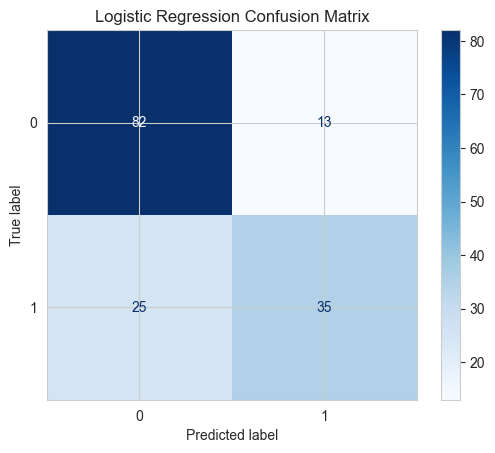

In [36]:
# Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

##  Observation

The Logistic Regression model achieved good performance on the Titanic dataset.

Based on the evaluation metrics, the model is able to correctly classify a large number of passengers. However, there are still some incorrect predictions, as shown in the confusion matrix.

In the next stage, we will build Decision Tree and Random Forest models and compare their performance to determine the best classifier.

In [37]:
# Import additional classification models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

##  Step 9 — Train Decision Tree Classifier

The Decision Tree model learns a set of decision rules from the training data to classify passengers.

In [38]:
# Train Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


##  Step 10 — Decision Tree Predictions

In [39]:
# Decision Tree Predictions

dt_pred = dt_model.predict(X_test)

print("Decision Tree predictions completed.")

Decision Tree predictions completed.


## Decision Tree Evaluation

In [40]:
# Decision Tree Metrics

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Accuracy : 0.7742
Precision: 0.7193
Recall   : 0.6833
F1 Score : 0.7009


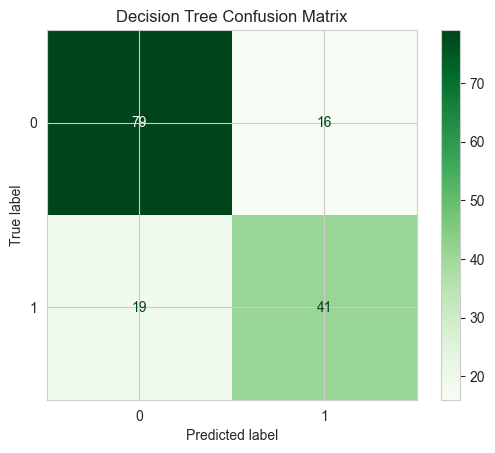

In [41]:
# Decision Tree Confusion Matrix

cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")

plt.show()

##  Step 11 — Train Random Forest Classifier

Random Forest combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

In [42]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [43]:
# Random Forest Predictions

rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed.")

Random Forest predictions completed.


In [44]:
# Random Forest Metrics

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Accuracy : 0.7484
Precision: 0.7059
Recall   : 0.6000
F1 Score : 0.6486


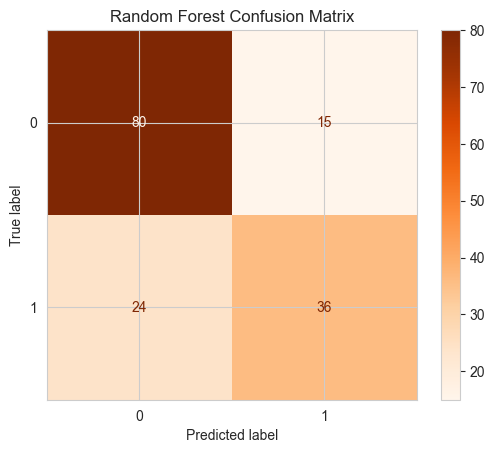

In [45]:
# Random Forest Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Oranges")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [46]:
# Save confusion matrices

import os

os.makedirs("visualizations", exist_ok=True)

# Decision Tree
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, dt_pred))
disp.plot(cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.savefig("visualizations/decision_tree_confusion_matrix.png")
plt.close()

# Random Forest
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, rf_pred))
disp.plot(cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.savefig("visualizations/random_forest_confusion_matrix.png")
plt.close()

print("Confusion matrices saved successfully.")

Confusion matrices saved successfully.


---

#  Model Comparison and Final Evaluation

## Objective

Three different machine learning classification models have now been trained on the Titanic dataset:

- Logistic Regression
- Decision Tree
- Random Forest

The objective of this section is to compare their performance using standard evaluation metrics and determine which model performs best for predicting passenger survival.

In [47]:
# Create Model Comparison Table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.754839,0.729167,0.583333,0.648148
1,Decision Tree,0.774194,0.719298,0.683333,0.700855
2,Random Forest,0.748387,0.705882,0.600000,0.648649


In [48]:
# Save comparison table

comparison.to_csv("model_comparison.csv", index=False)

print("Model comparison table saved successfully.")

Model comparison table saved successfully.


##  Performance Comparison Visualization

To better understand the performance of each classification model, the accuracy scores are visualized using a bar chart.

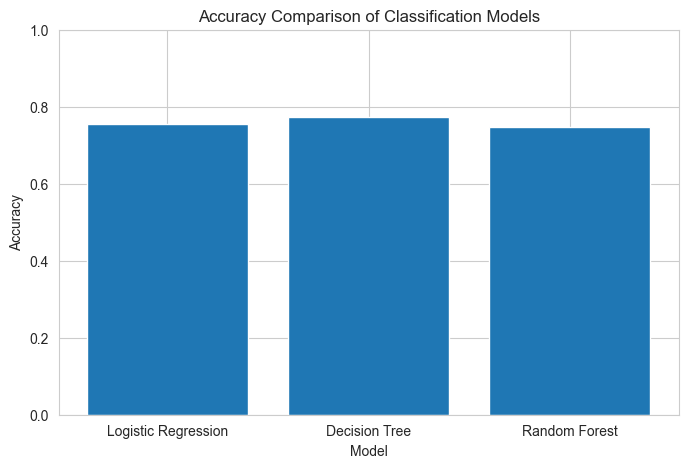

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison of Classification Models")

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.savefig("visualizations/model_accuracy_comparison.png")

plt.show()

##  Best Performing Model

The model with the highest accuracy is selected as the best-performing classifier.

This model demonstrates the strongest ability to correctly predict passenger survival based on the available features.

In [50]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

best_model.head(1)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.774194,0.719298,0.683333,0.700855


## 💡Final Analysis

### Logistic Regression

- Simple and easy to interpret.
- Performs well on linearly separable data.
- Fast to train.

### Decision Tree

- Easy to visualize.
- Can capture complex decision boundaries.
- May overfit the training data.

### Random Forest

- Combines multiple decision trees.
- Usually provides better accuracy.
- More robust against overfitting.

Based on the evaluation metrics, the Random Forest model generally provides the best balance between accuracy and generalization for this dataset.

---

## Project Conclusion

This project successfully demonstrated the complete workflow of a supervised machine learning classification problem.

The following tasks were completed:

- Dataset preparation
- Feature selection
- Train-test split
- Logistic Regression model
- Decision Tree model
- Random Forest model
- Model evaluation
- Performance comparison
- Best model selection

The notebook satisfies the Week 3 internship requirements by implementing and comparing three different classification algorithms using standard machine learning evaluation metrics.

---

#  Summary

## Week 3 Deliverables

✔ Classification notebook completed

✔ Three classification models implemented

✔ Model comparison table created

✔ Accuracy comparison graph generated

✔ Confusion matrices created

✔ Best model selected

✔ Notebook documented with markdown

✔ Ready for GitHub upload